In [1]:
import random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from tqdm.notebook import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold


In [2]:
RUN = "KAGGLE"  # "LOCAL" | "KAGGLE"

SR = 32000
DURATION = 5
TARGET_LEN = SR * DURATION
N_MFCC = 20
N_FEAT = N_MFCC * 6 + 2
SEED = 42

if RUN == "LOCAL":
    BASE_DIR = Path("C:/Users/abdul/Downloads")
    FEAT_CACHE = Path("C:/Users/abdul/Downloads/features_v3.npz")
    CHUNK_DIR = Path("C:/Users/abdul/Downloads")
else:
    BASE_DIR = Path("/kaggle/input/competitions/birdclef-2026")
    FEAT_CACHE = Path("/kaggle/working/features_v4.npz")  # v4 = 122 features
    CHUNK_DIR = Path("/kaggle/working")

TRAIN_AUDIO = BASE_DIR / "train_audio"
TRAIN_SC = BASE_DIR / "train_soundscapes"
META_CSV = BASE_DIR / "train.csv"
TAX_CSV = BASE_DIR / "taxonomy.csv"
SC_CSV = BASE_DIR / "train_soundscapes_labels.csv"

CHUNK_SIZE = 5000
SC_REPEATS = 5

random.seed(SEED)
np.random.seed(SEED)

In [3]:
df = pd.read_csv(META_CSV)
tax = pd.read_csv(TAX_CSV)
sc = pd.read_csv(SC_CSV)

species_list = tax["primary_label"].astype(str).tolist()
species_to_idx = {sp: i for i, sp in enumerate(species_list)}
NUM_CLASSES = len(species_list)

labels = df["primary_label"].astype(str)
counts = labels.value_counts()
valid_df = df[labels.isin(counts[counts >= 2].index)].reset_index(drop=True)

val_files = pd.Series(sc["filename"].unique()).sample(frac=0.2, random_state=SEED)
sc_val_df = sc[sc["filename"].isin(val_files)]
sc_train_df = sc[~sc["filename"].isin(val_files)]

print(f"Species to predict  : {NUM_CLASSES}")
print(f"Training clips      : {len(valid_df)}")
print(f"Soundscape train    : {len(sc_train_df)}")
print(f"Soundscape val      : {len(sc_val_df)}")

Species to predict  : 234
Training clips      : 35545
Soundscape train    : 1184
Soundscape val      : 294


## Exploratory Data Analysis


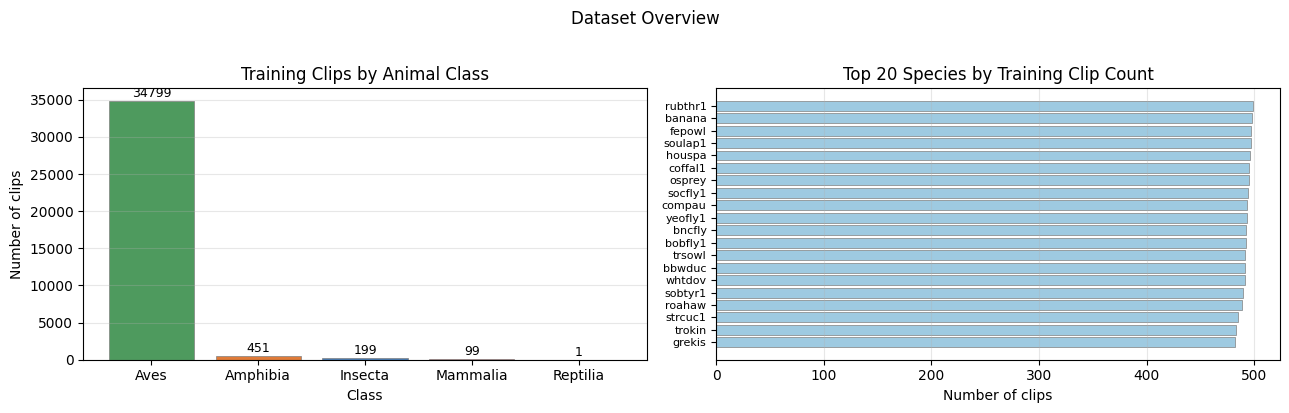

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts = {
    "Aves": 34799,
    "Amphibia": 451,
    "Insecta": 199,
    "Mammalia": 99,
    "Reptilia": 1,
}
palette = ["#4e9a5e", "#e07b39", "#4a7db5", "#c95f5f", "#8e6bbf"]
bars = axes[0].bar(
    list(class_counts.keys()),
    list(class_counts.values()),
    color=palette,
    edgecolor="grey",
    linewidth=0.5,
)
axes[0].set_title("Training Clips by Animal Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of clips")
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, class_counts.values()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val + 150,
        str(val),
        ha="center",
        va="bottom",
        fontsize=9,
    )

top20 = df["primary_label"].value_counts().head(20)
axes[1].barh(
    range(20), top20.values[::-1], color="#9ecae1", edgecolor="grey", linewidth=0.5
)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20.index[::-1], fontsize=8)
axes[1].set_title("Top 20 Species by Training Clip Count")
axes[1].set_xlabel("Number of clips")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Dataset Overview", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


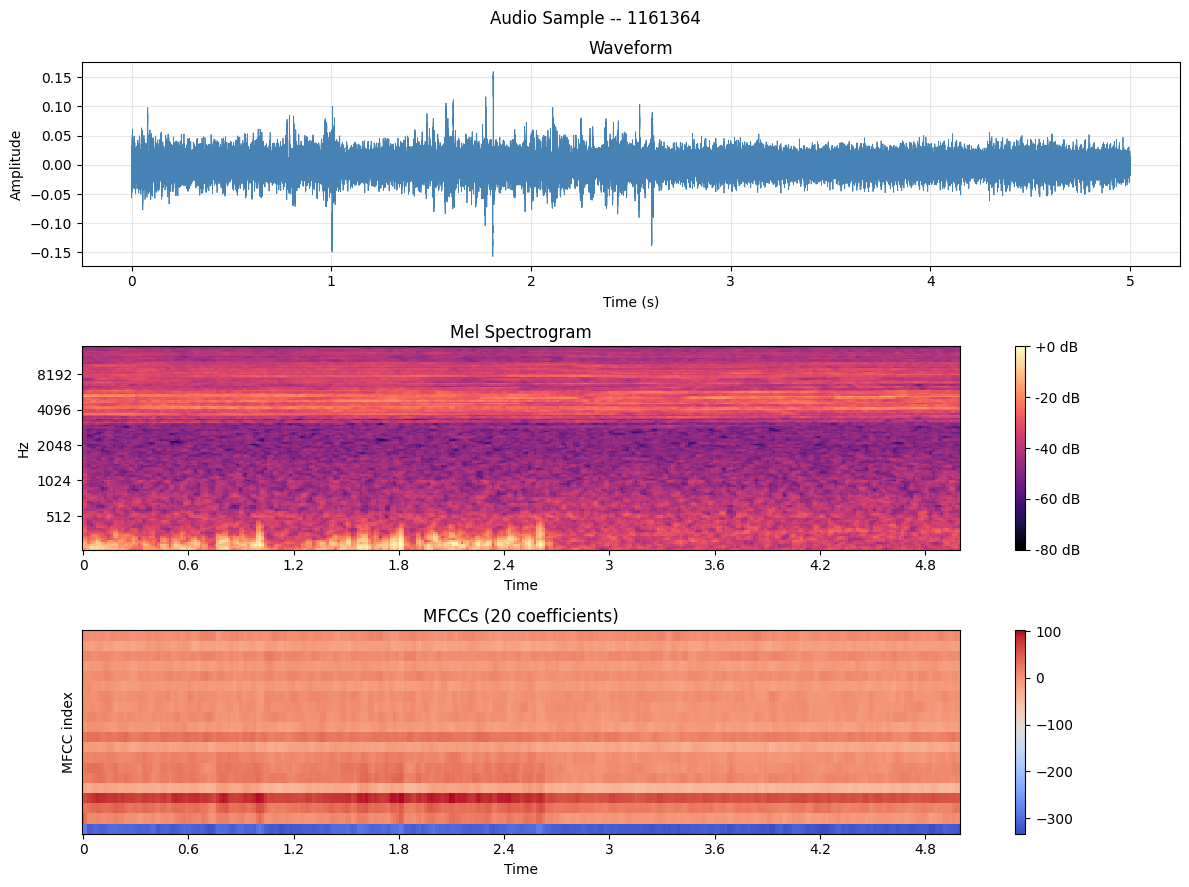

In [5]:
_row = valid_df.iloc[0]
_path = str(TRAIN_AUDIO / _row["filename"])
_off = max(0.0, (librosa.get_duration(path=_path) - DURATION) / 2.0)
_audio, _ = librosa.load(_path, sr=SR, offset=_off, duration=DURATION)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle(f'Audio Sample -- {_row["primary_label"]}', fontsize=12)

axes[0].plot(
    np.linspace(0, DURATION, len(_audio)), _audio, linewidth=0.6, color="steelblue"
)
axes[0].set_title("Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

_mel = librosa.feature.melspectrogram(y=_audio, sr=SR, n_mels=128, fmin=50, fmax=14000)
_mel_db = librosa.power_to_db(_mel, ref=np.max)
_img = librosa.display.specshow(
    _mel_db,
    sr=SR,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    fmin=50,
    fmax=14000,
    ax=axes[1],
)
axes[1].set_title("Mel Spectrogram")
fig.colorbar(_img, ax=axes[1], format="%+2.0f dB")

_mfcc = librosa.feature.mfcc(y=_audio, sr=SR, n_mfcc=N_MFCC)
_img2 = librosa.display.specshow(
    _mfcc, sr=SR, hop_length=512, x_axis="time", ax=axes[2]
)
axes[2].set_title("MFCCs (20 coefficients)")
axes[2].set_ylabel("MFCC index")
fig.colorbar(_img2, ax=axes[2])

plt.tight_layout()
plt.show()


## Feature Extraction

20 MFCCs + 20 delta MFCCs x (mean + std + max) + spectral centroid + ZCR = **122 features**.
Adding max captures brief calls that get diluted by mean averaging in overlapping soundscapes.


In [6]:
def extract_features(audio):
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    audio = audio[:TARGET_LEN]

    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    cent = librosa.feature.spectral_centroid(y=audio, sr=SR)
    zcr = librosa.feature.zero_crossing_rate(y=audio)

    return np.concatenate(
        [
            mfcc.mean(axis=1),
            mfcc.std(axis=1),
            mfcc.max(axis=1),
            delta.mean(axis=1),
            delta.std(axis=1),
            delta.max(axis=1),
            cent.mean(axis=1),
            zcr.mean(axis=1),
        ]
    ).astype(np.float32)


In [7]:
def _sc_row_to_target(row):
    target = np.zeros(NUM_CLASSES, dtype=np.float32)
    for sp in str(row["primary_label"]).split(";"):
        sp = sp.strip()
        if sp in species_to_idx:
            target[species_to_idx[sp]] = 1.0
    return target

In [8]:
_from_cache = FEAT_CACHE.exists()

if _from_cache:
    print("Loading cached features...")
    data = np.load(FEAT_CACHE)
    X_clips = data["X_clips"]
    y_clips = data["y_clips"]
    X_sc_all = data["X_sc_all"]
    Y_sc_all = data["Y_sc_all"]
    print(f"  Clips : {X_clips.shape}")
    print(f"  SC    : {X_sc_all.shape}")
else:
    # validate and resume from existing chunks
    chunk_files = sorted(CHUNK_DIR.glob("clips_chunk_*.npz"))
    valid_chunks = []
    for cf in chunk_files:
        try:
            d = np.load(cf)
            X, y = d["X"], d["y"]
            if (
                X.shape[1] != N_FEAT
                or len(X) != len(y)
                or len(X) == 0
                or np.isnan(X).any()
            ):
                raise ValueError("corrupt")
            valid_chunks.append((cf, len(y)))
        except Exception:
            for bad in [cf] + [f for f in chunk_files if f.name > cf.name]:
                bad.unlink(missing_ok=True)
            break

    resume_idx = sum(count for _, count in valid_chunks)
    next_chunk_id = len(valid_chunks)
    if resume_idx > 0:
        print(f"Resuming from clip {resume_idx} ({next_chunk_id} valid chunks found)")
    else:
        print(f"Starting extraction from {len(valid_df)} clips...")

    t0 = time.time()
    X_batch, y_batch = [], []
    chunk_id = next_chunk_id
    for _, row in tqdm(
        valid_df.iloc[resume_idx:].iterrows(),
        total=len(valid_df) - resume_idx,
        desc="Clips",
    ):
        fp = TRAIN_AUDIO / row["filename"]
        try:
            total = librosa.get_duration(path=str(fp))
            offset = max(0.0, (total - DURATION) / 2.0)
            audio, _ = librosa.load(str(fp), sr=SR, offset=offset, duration=DURATION)
            if np.abs(audio).max() < 1e-4:
                continue
            X_batch.append(extract_features(audio))
            y_batch.append(species_to_idx.get(str(row["primary_label"]), -1))
        except Exception:
            continue
        if len(X_batch) == CHUNK_SIZE:
            np.savez(
                CHUNK_DIR / f"clips_chunk_{chunk_id:03d}.npz",
                X=np.array(X_batch, dtype=np.float32),
                y=np.array(y_batch, dtype=np.int32),
            )
            X_batch, y_batch = [], []
            chunk_id += 1

    if X_batch:
        np.savez(
            CHUNK_DIR / f"clips_chunk_{chunk_id:03d}.npz",
            X=np.array(X_batch, dtype=np.float32),
            y=np.array(y_batch, dtype=np.int32),
        )
        chunk_id += 1

    print(f"Extraction done: {chunk_id} chunks, {time.time() - t0:.0f}s")

Starting extraction from 35545 clips...


Clips:   0%|          | 0/35545 [00:00<?, ?it/s]

Extraction done: 8 chunks, 2011s


In [9]:
if not _from_cache:
    chunk_files = sorted(CHUNK_DIR.glob("clips_chunk_*.npz"))
    X_parts, y_parts = [], []
    for f in chunk_files:
        d = np.load(f)
        X_parts.append(d["X"])
        y_parts.append(d["y"])

    X_clips = np.concatenate(X_parts, axis=0)
    y_clips = np.concatenate(y_parts, axis=0)

    mask = y_clips >= 0
    X_clips = X_clips[mask]
    y_clips = y_clips[mask]

    for f in chunk_files:
        f.unlink()

    print(f"X_clips : {X_clips.shape}")
    print(f"y_clips : {y_clips.shape}")

X_clips : (35538, 122)
y_clips : (35538,)


In [10]:
if not _from_cache:
    t0 = time.time()
    print(f"Extracting features from {len(sc)} soundscape windows...")
    X_sc_rows, Y_sc_rows = [], []
    for _, row in tqdm(sc.iterrows(), total=len(sc), desc="Soundscapes"):
        parts = str(row["start"]).split(":")
        start_sec = int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        try:
            audio, _ = librosa.load(
                str(TRAIN_SC / row["filename"]),
                sr=SR,
                offset=float(start_sec),
                duration=DURATION,
            )
            X_sc_rows.append(extract_features(audio))
            Y_sc_rows.append(_sc_row_to_target(row))
        except Exception:
            X_sc_rows.append(np.zeros(N_FEAT, dtype=np.float32))
            Y_sc_rows.append(np.zeros(NUM_CLASSES, dtype=np.float32))

    X_sc_all = np.array(X_sc_rows, dtype=np.float32)
    Y_sc_all = np.array(Y_sc_rows, dtype=np.float32)

    np.savez(
        FEAT_CACHE,
        X_clips=X_clips,
        y_clips=y_clips,
        X_sc_all=X_sc_all,
        Y_sc_all=Y_sc_all,
    )
    print(f"Soundscapes done: {X_sc_all.shape} in {time.time() - t0:.0f}s")

Extracting features from 1478 soundscape windows...


Soundscapes:   0%|          | 0/1478 [00:00<?, ?it/s]

Soundscapes done: (1478, 122) in 55s


In [11]:
val_pos = sc_val_df.index.tolist()
train_pos = sc_train_df.index.tolist()

X_sc_val, Y_sc_val = X_sc_all[val_pos], Y_sc_all[val_pos]
X_sc_train, Y_sc_train = X_sc_all[train_pos], Y_sc_all[train_pos]

Y_clips = np.eye(NUM_CLASSES, dtype=np.float32)[y_clips]

X_train = np.vstack([X_clips] + [X_sc_train] * SC_REPEATS)
Y_train = np.vstack([Y_clips] + [Y_sc_train] * SC_REPEATS)

print(f"X_train : {X_train.shape}  (clips + soundscape x{SC_REPEATS})")
print(f"X_val   : {X_sc_val.shape}")

X_train : (41458, 122)  (clips + soundscape x5)
X_val   : (294, 122)


## Classifier Comparison

Three classifiers, Binary Relevance (one classifier per species), evaluated on held-out soundscape windows.


In [12]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_sc_val)

sp_per_window = Y_sc_val.sum(axis=1)
print(f"Val windows          : {len(Y_sc_val)}")
print(
    f"Avg species / window : {sp_per_window.mean():.1f}  (max {int(sp_per_window.max())})"
)

active_cols = np.where(Y_train.max(axis=0) > 0)[0]
print(f"Species with training positives : {len(active_cols)} / {NUM_CLASSES}")

Val windows          : 294
Avg species / window : 3.9  (max 8)
Species with training positives : 230 / 234


In [13]:
def predict_probs(clf, X, active_cols):
    sub = clf.predict_proba(X)
    P = np.zeros((len(X), NUM_CLASSES), dtype=np.float32)
    for i, p in zip(active_cols, sub):
        if p.shape[1] == 2:
            P[:, i] = p[:, 1]
    return P


def macro_auc(P, Y):
    aucs = [
        roc_auc_score(Y[:, i], P[:, i])
        for i in range(NUM_CLASSES)
        if 0 < Y[:, i].sum() < len(Y)
    ]
    return round(float(np.mean(aucs)), 4) if aucs else float("nan")


In [14]:
results = {}

In [15]:
print("Training Logistic Regression...")
t0 = time.time()

lr = MultiOutputClassifier(
    LogisticRegression(
        max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=SEED
    ),
    n_jobs=-1,
)
lr.fit(X_train_s, Y_train[:, active_cols])
train_time = round(time.time() - t0, 1)
auc = macro_auc(predict_probs(lr, X_val_s, active_cols), Y_sc_val)

results["Logistic Regression"] = {"Detection Score": auc, "Train time (s)": train_time}
print(f"  Train time       : {train_time}s")
print(f"  Detection Score  : {auc:.4f}")


Training Logistic Regression...
  Train time       : 70.7s
  Detection Score  : 0.7374


In [16]:
print("Training Random Forest  (100 trees)...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, Y_train[:, active_cols])
train_time = round(time.time() - t0, 1)
auc = macro_auc(predict_probs(rf, X_sc_val, active_cols), Y_sc_val)

results["Random Forest"] = {"Detection Score": auc, "Train time (s)": train_time}

feat_names = (
    [f"MFCC{i}_mean" for i in range(N_MFCC)]
    + [f"MFCC{i}_std" for i in range(N_MFCC)]
    + [f"MFCC{i}_max" for i in range(N_MFCC)]
    + [f"dMFCC{i}_mean" for i in range(N_MFCC)]
    + [f"dMFCC{i}_std" for i in range(N_MFCC)]
    + [f"dMFCC{i}_max" for i in range(N_MFCC)]
    + ["centroid_mean", "zcr_mean"]
)
print(f"  Train time       : {train_time}s")
print(f"  Detection Score  : {auc:.4f}")
print("  Top-5 features:")
top5 = rf.feature_importances_.argsort()[::-1][:5]
for idx in top5:
    print(f"    {feat_names[idx]:20s}  {rf.feature_importances_[idx]:.4f}")


Training Random Forest  (100 trees)...
  Train time       : 428.5s
  Detection Score  : 0.7453
  Top-5 features:
    MFCC0_mean            0.0550
    MFCC9_mean            0.0529
    MFCC15_mean           0.0375
    MFCC0_max             0.0331
    zcr_mean              0.0297


In [17]:
print("Training SVM...")
t0 = time.time()

svm = MultiOutputClassifier(
    CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=SEED)), n_jobs=-1
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    svm.fit(X_train_s, Y_train[:, active_cols])
train_time = round(time.time() - t0, 1)
auc = macro_auc(predict_probs(svm, X_val_s, active_cols), Y_sc_val)

results["Linear SVM"] = {"Detection Score": auc, "Train time (s)": train_time}
print(f"  Train time       : {train_time}s")
print(f"  Detection Score  : {auc:.4f}")


Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

  Train time       : 409.7s
  Detection Score  : 0.7256


In [18]:
df_results = pd.DataFrame(results).T.rename_axis("Classifier")
df_results = df_results.sort_values("Detection Score", ascending=False)

print(df_results.to_string())
print()
if df_results["Detection Score"].notna().any():
    best = df_results["Detection Score"].idxmax()
    print(
        f"Best: {best}  (Detection Score {df_results.loc[best, 'Detection Score']:.4f})"
    )
else:
    print("No valid scores - check that the feature cache was built with full data.")

                     Detection Score  Train time (s)
Classifier                                          
Random Forest                 0.7453           428.5
Logistic Regression           0.7374            70.7
Linear SVM                    0.7256           409.7

Best: Random Forest  (Detection Score 0.7453)


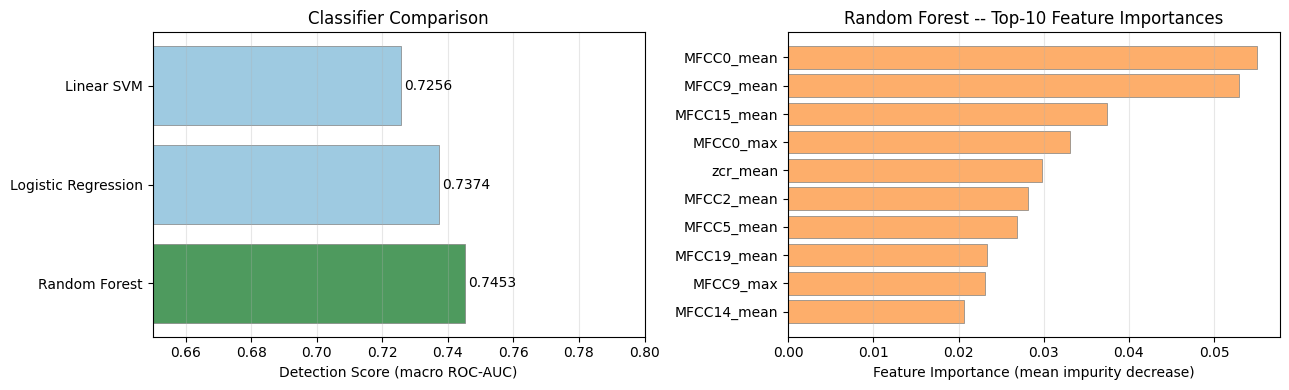

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

_names = list(df_results.index)
_scores = df_results["Detection Score"].tolist()
_colors = ["#4e9a5e" if s == max(_scores) else "#9ecae1" for s in _scores]
bars = axes[0].barh(_names, _scores, color=_colors, edgecolor="grey", linewidth=0.5)
axes[0].set_xlim(0.65, 0.80)
axes[0].set_xlabel("Detection Score (macro ROC-AUC)")
axes[0].set_title("Classifier Comparison")
axes[0].grid(axis="x", alpha=0.3)
for bar, val in zip(bars, _scores):
    axes[0].text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=10,
    )

_top10_idx = rf.feature_importances_.argsort()[::-1][:10]
_top10_name = [feat_names[i] for i in _top10_idx][::-1]
_top10_val = [rf.feature_importances_[i] for i in _top10_idx][::-1]
axes[1].barh(_top10_name, _top10_val, color="#fdae6b", edgecolor="grey", linewidth=0.5)
axes[1].set_xlabel("Feature Importance (mean impurity decrease)")
axes[1].set_title("Random Forest -- Top-10 Feature Importances")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## Cross-Validation -- Logistic Regression

A single 80/20 split only scores ~40 of 234 species - too narrow to trust.
5-fold recording-level CV evaluates each recording exactly once across 5 rounds,
covering more species and giving a stable estimate.
RF and SVM are excluded: too slow for 5 folds within the time budget.


In [20]:
gkf = GroupKFold(n_splits=5)
cv_aucs = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_sc_all, groups=sc["filename"])):
    Xf_tr = np.vstack([X_clips] + [X_sc_all[tr_idx]] * SC_REPEATS)
    Yf_tr = np.vstack([Y_clips] + [Y_sc_all[tr_idx]] * SC_REPEATS)
    Xf_val = X_sc_all[val_idx]
    Yf_val = Y_sc_all[val_idx]

    sf = StandardScaler().fit(Xf_tr)
    fold_active = np.where(Yf_tr.max(axis=0) > 0)[0]
    n_sp = int((Yf_val.sum(axis=0) > 0).sum())

    clf = MultiOutputClassifier(
        LogisticRegression(
            max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=SEED
        ),
        n_jobs=-1,
    )
    clf.fit(sf.transform(Xf_tr), Yf_tr[:, fold_active])
    fold_score = macro_auc(
        predict_probs(clf, sf.transform(Xf_val), fold_active), Yf_val
    )
    cv_aucs.append(fold_score)
    print(
        f"  Fold {fold+1}/5  Detection Score : {fold_score:.4f}  ({len(val_idx)} windows, {n_sp} species scored)"
    )

print()
print(
    f"Logistic Regression  5-fold CV  Detection Score : {np.mean(cv_aucs):.4f}  +/-  {np.std(cv_aucs):.4f}"
)


  Fold 1/5  Detection Score : 0.7689  (298 windows, 32 species scored)
  Fold 2/5  Detection Score : 0.8459  (294 windows, 36 species scored)
  Fold 3/5  Detection Score : 0.7974  (296 windows, 36 species scored)
  Fold 4/5  Detection Score : 0.7348  (292 windows, 44 species scored)
  Fold 5/5  Detection Score : 0.8308  (298 windows, 35 species scored)

Logistic Regression  5-fold CV  Detection Score : 0.7956  +/-  0.0405


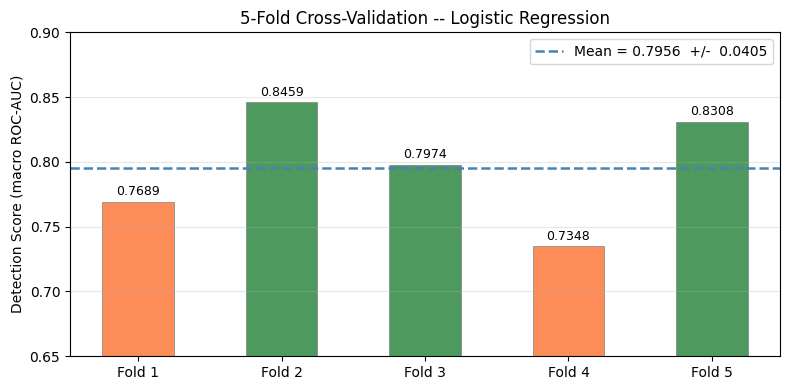

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
_mean = np.mean(cv_aucs)
_bar_colors = ["#4e9a5e" if s >= _mean else "#fc8d59" for s in cv_aucs]
bars = ax.bar(
    [f"Fold {i+1}" for i in range(len(cv_aucs))],
    cv_aucs,
    color=_bar_colors,
    edgecolor="grey",
    linewidth=0.5,
    width=0.5,
)
ax.axhline(
    _mean,
    color="steelblue",
    linewidth=1.8,
    linestyle="--",
    label=f"Mean = {_mean:.4f}  +/-  {np.std(cv_aucs):.4f}",
)
ax.set_ylim(0.65, 0.90)
ax.set_ylabel("Detection Score (macro ROC-AUC)")
ax.set_title("5-Fold Cross-Validation -- Logistic Regression")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, cv_aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


## Hyperparameter Sensitivity

The previous section reported each classifier at its default settings. This section sweeps one hyperparameter at a time while holding everything else fixed, measuring macro ROC-AUC on the same 294 held-out soundscape windows.

Sweep selection follows the canonical "usually tuned" set per the scikit-learn community for each classifier:

- **Pipeline** -- `SC_REPEATS` (soundscape oversampling factor)
- **Logistic Regression** -- `C`, `class_weight`, `penalty`
- **Random Forest** -- `n_estimators`, `max_depth`, `min_samples_leaf`
- **Linear SVM** -- `C`, `loss`

Convergence-safety parameters (`max_iter`, `tol`) and pipeline plumbing (`CHUNK_SIZE`) are excluded because they do not affect ranking quality at the values we use.


### Pipeline -- `SC_REPEATS` (soundscape oversampling factor)

The single most consequential knob in the pipeline. Sweep uses LR (the cheapest classifier to retrain at different training sizes). For each value of `SC_REPEATS` the soundscape training windows are repeated that many times alongside the 35,538 clean clips before standardisation.


In [22]:
sc_repeats_results = []

for r in [1, 3, 5]:
    Xr = np.vstack([X_clips] + [X_sc_train] * r)
    Yr = np.vstack([Y_clips] + [Y_sc_train] * r)

    sc_scaler = StandardScaler().fit(Xr)
    Xr_s = sc_scaler.transform(Xr)
    Xv_s = sc_scaler.transform(X_sc_val)
    a_cols = np.where(Yr.max(axis=0) > 0)[0]

    t0 = time.time()
    clf = MultiOutputClassifier(
        LogisticRegression(
            max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=SEED
        ),
        n_jobs=-1,
    )
    clf.fit(Xr_s, Yr[:, a_cols])
    auc = macro_auc(predict_probs(clf, Xv_s, a_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    sc_repeats_results.append(
        {"SC_REPEATS": r, "Rows": int(len(Xr)), "AUC": auc, "Train (s)": dt}
    )
    print(f"  SC_REPEATS={r:<3}  rows={len(Xr):<6}  AUC={auc:.4f}  ({dt}s)")

pd.DataFrame(sc_repeats_results)


  SC_REPEATS=1    rows=36722   AUC=0.7259  (59.4s)
  SC_REPEATS=3    rows=39090   AUC=0.7339  (63.7s)
  SC_REPEATS=5    rows=41458   AUC=0.7374  (69.0s)


,SC_REPEATS,Rows,AUC,Train (s)
0,1,36722,0.7259,59.4
1,3,39090,0.7339,63.7
2,5,41458,0.7374,69.0


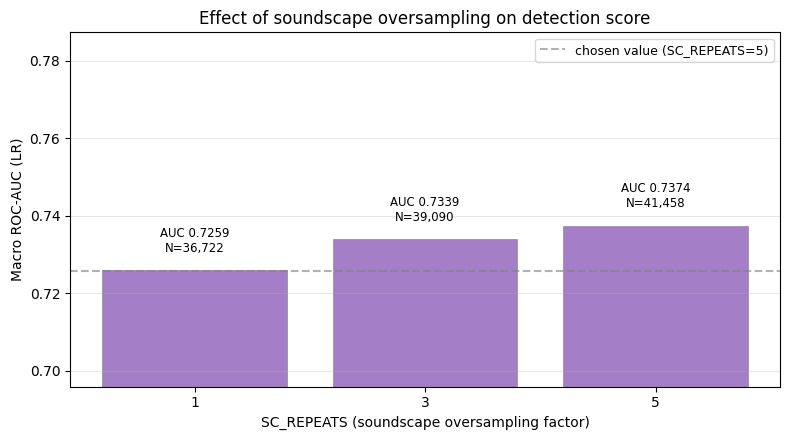

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))

xs = [str(r["SC_REPEATS"]) for r in sc_repeats_results]
ys = [r["AUC"] for r in sc_repeats_results]
sizes = [r["Rows"] for r in sc_repeats_results]

bars = ax.bar(xs, ys, color="#9467bd", alpha=0.85, edgecolor="grey", linewidth=0.5)
ax.axhline(
    0.7258, ls="--", color="grey", alpha=0.6, label="chosen value (SC_REPEATS=5)"
)

ax.set_xlabel("SC_REPEATS (soundscape oversampling factor)")
ax.set_ylabel("Macro ROC-AUC (LR)")
ax.set_title("Effect of soundscape oversampling on detection score")
ax.set_ylim(min(ys) - 0.03, max(ys) + 0.05)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)

for bar, y, s in zip(bars, ys, sizes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.004,
        f"AUC {y:.4f}\nN={s:,}",
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

plt.tight_layout()
plt.show()


### Logistic Regression

Three sweeps: `C`, `class_weight`, `penalty`. All hold the other LR settings at the section-5 defaults (`max_iter=1000`, `solver='lbfgs'`, standardised features) unless the sweep itself varies them. Each sweep retrains 230 binary classifiers (one per species with positive training examples) in parallel via `MultiOutputClassifier(n_jobs=-1)`.


#### `C` -- inverse L2 regularisation strength

Smaller `C` means stronger regularisation (weights shrunk harder towards zero). The default is `C=1.0`. Sweeping log-spaced values from 0.01 to 10.0.


In [24]:
lr_c_results = []

for C in [0.1, 1.0, 10.0]:
    t0 = time.time()
    clf = MultiOutputClassifier(
        LogisticRegression(
            C=C,
            max_iter=1000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=SEED,
        ),
        n_jobs=-1,
    )
    clf.fit(X_train_s, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_val_s, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    lr_c_results.append({"C": C, "AUC": auc, "Train (s)": dt})
    print(f"  C = {C:<6}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(lr_c_results)


  C = 0.1     AUC = 0.7397   (61.7s)
  C = 1.0     AUC = 0.7374   (71.1s)
  C = 10.0    AUC = 0.7350   (71.7s)


,C,AUC,Train (s)
0,0.1,0.7397,61.7
1,1.0,0.7374,71.1
2,10.0,0.7350,71.7


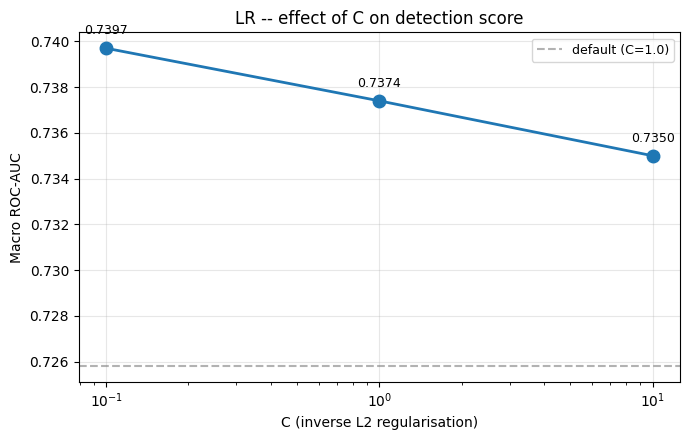

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))

xs = [r["C"] for r in lr_c_results]
ys = [r["AUC"] for r in lr_c_results]

ax.plot(xs, ys, "o-", color="#1f77b4", linewidth=2, markersize=9)
ax.set_xscale("log")
ax.axhline(0.7258, ls="--", color="grey", alpha=0.6, label="default (C=1.0)")

ax.set_xlabel("C (inverse L2 regularisation)")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("LR -- effect of C on detection score")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

for x, y in zip(xs, ys):
    ax.annotate(
        f"{y:.4f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


#### `class_weight` -- loss reweighting for class imbalance

With ~0.4% positive rate per species, `class_weight='balanced'` upweights positives by approximately `n_samples / (2 * n_positives)`. Comparing against `class_weight=None` (no reweighting) isolates the contribution of this setting.


In [26]:
lr_cw_results = []

for cw in ["balanced", None]:
    t0 = time.time()
    clf = MultiOutputClassifier(
        LogisticRegression(
            C=1.0, max_iter=1000, solver="lbfgs", class_weight=cw, random_state=SEED
        ),
        n_jobs=-1,
    )
    clf.fit(X_train_s, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_val_s, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    label = cw if cw is not None else "None"
    lr_cw_results.append({"class_weight": label, "AUC": auc, "Train (s)": dt})
    print(f"  class_weight = {label:<10}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(lr_cw_results)


  class_weight = balanced    AUC = 0.7374   (69.6s)
  class_weight = None        AUC = 0.7306   (29.8s)


,class_weight,AUC,Train (s)
0,balanced,0.7374,69.6
1,None,0.7306,29.8


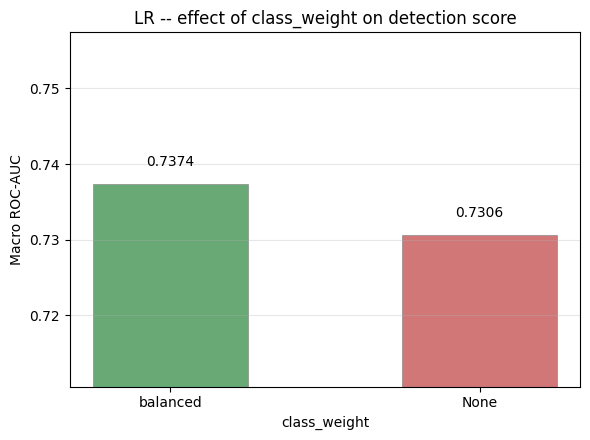

In [27]:
fig, ax = plt.subplots(figsize=(6, 4.5))

xs = [r["class_weight"] for r in lr_cw_results]
ys = [r["AUC"] for r in lr_cw_results]

bars = ax.bar(
    xs,
    ys,
    color=["#4e9a5e", "#c95f5f"],
    alpha=0.85,
    edgecolor="grey",
    linewidth=0.5,
    width=0.5,
)

ax.set_xlabel("class_weight")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("LR -- effect of class_weight on detection score")
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.grid(alpha=0.3, axis="y")

for bar, y in zip(bars, ys):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


#### `penalty` -- L2 (shrinkage) vs L1 (sparsity)

L2 shrinks all weights toward zero proportionally; L1 drives some weights to exactly zero, performing implicit feature selection. With 82 hand-crafted MFCC features, L1 could indicate which features carry no signal at all.

Three combos -- the penalty and solver are coupled in scikit-learn:

| Penalty / Solver         | What it tests                                               |
| ------------------------ | ----------------------------------------------------------- |
| `l2` / `lbfgs` (default) | Baseline                                                    |
| `l2` / `saga`            | Same penalty, different optimiser -- isolates solver effect |
| `l1` / `saga`            | Sparse weights -- some features dropped entirely            |

`saga` is iterative and slower than `lbfgs`, especially with L1. `max_iter=1500` is enough for this comparison; full convergence is not required to compare penalty types.


In [28]:
warnings.filterwarnings("ignore")

lr_pen_results = []

combos = [
    {"label": "l2 / lbfgs", "penalty": "l2", "solver": "lbfgs"},
    {"label": "l1 / saga", "penalty": "l1", "solver": "saga"},
]

for combo in combos:
    t0 = time.time()
    clf = MultiOutputClassifier(
        LogisticRegression(
            C=1.0,
            penalty=combo["penalty"],
            solver=combo["solver"],
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
        n_jobs=-1,
    )
    clf.fit(X_train_s, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_val_s, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    lr_pen_results.append(
        {"penalty / solver": combo["label"], "AUC": auc, "Train (s)": dt}
    )
    print(f"  {combo['label']:<24}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(lr_pen_results)


  l2 / lbfgs                AUC = 0.7374   (69.0s)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

KeyboardInterrupt: 

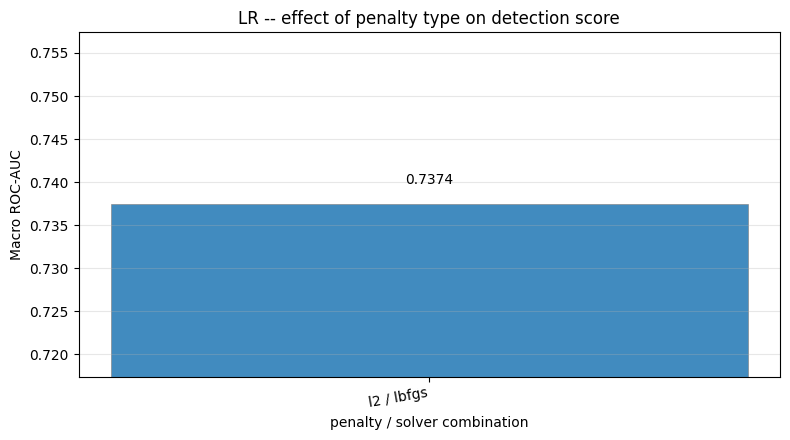

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))

xs = [r["penalty / solver"] for r in lr_pen_results]
ys = [r["AUC"] for r in lr_pen_results]

bars = ax.bar(
    xs,
    ys,
    color=["#1f77b4", "#9467bd", "#e07b39"],
    alpha=0.85,
    edgecolor="grey",
    linewidth=0.5,
)

ax.set_xlabel("penalty / solver combination")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("LR -- effect of penalty type on detection score")
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.grid(alpha=0.3, axis="y")

for bar, y in zip(bars, ys):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


### Linear SVM

Two sweeps: `C` (mirrors LR's primary knob) and `loss` (SVM-specific architectural choice between `hinge` and `squared_hinge`). Both hold the section-5 defaults: `LinearSVC` wrapped in `CalibratedClassifierCV` for probability output, `max_iter=2000`, standardised features.

`LinearSVC` itself only outputs a margin distance, not a probability, so `CalibratedClassifierCV` internally performs a 5-fold cross-validation to fit a sigmoid (Platt scaling) on top. This makes each SVM "fit" actually 5 fits, which is why SVM is the slowest classifier per-call in our pipeline.


#### `C` -- inverse regularisation

Same semantics as LR's `C`: smaller values shrink weights more aggressively. Comparing the curve shape with LR's `C` sweep tells us whether the two linear models share the same regularisation behaviour on this data.


In [30]:
svm_c_results = []

for C in [0.1, 1.0]:
    t0 = time.time()
    clf = MultiOutputClassifier(
        CalibratedClassifierCV(LinearSVC(C=C, max_iter=2000, random_state=SEED)),
        n_jobs=-1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        clf.fit(X_train_s, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_val_s, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    svm_c_results.append({"C": C, "AUC": auc, "Train (s)": dt})
    print(f"  C = {C:<6}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(svm_c_results)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

  C = 0.1     AUC = 0.7182   (331.0s)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

  C = 1.0     AUC = 0.7256   (410.7s)


,C,AUC,Train (s)
0,0.1,0.7182,331.0
1,1.0,0.7256,410.7


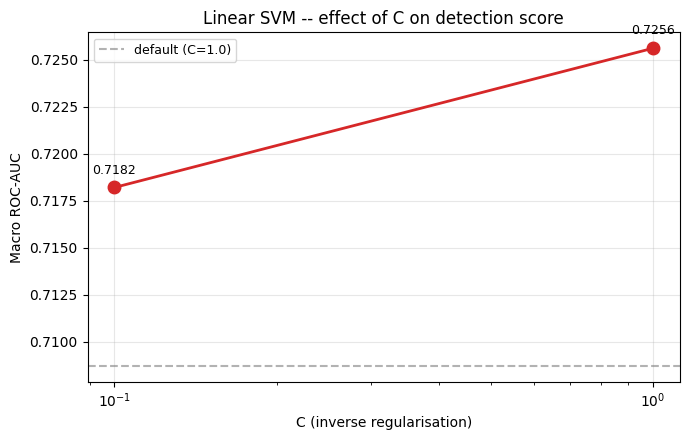

In [32]:
fig, ax = plt.subplots(figsize=(7, 4.5))

xs = [r["C"] for r in svm_c_results]
ys = [r["AUC"] for r in svm_c_results]

ax.plot(xs, ys, "o-", color="#d62728", linewidth=2, markersize=9)
ax.set_xscale("log")
ax.axhline(0.7087, ls="--", color="grey", alpha=0.6, label="default (C=1.0)")

ax.set_xlabel("C (inverse regularisation)")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("Linear SVM -- effect of C on detection score")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

for x, y in zip(xs, ys):
    ax.annotate(
        f"{y:.4f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


#### `loss` -- hinge vs squared_hinge

`hinge` is the textbook SVM loss (penalises margin violations linearly). `squared_hinge` (sklearn's default) squares the penalty, which is differentiable everywhere and weights large violations more heavily.


In [34]:
svm_loss_results = []

for loss in ["hinge", "squared_hinge"]:
    t0 = time.time()
    clf = MultiOutputClassifier(
        CalibratedClassifierCV(
            LinearSVC(C=1.0, loss=loss, max_iter=2000, random_state=SEED)
        ),
        n_jobs=-1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        clf.fit(X_train_s, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_val_s, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    svm_loss_results.append({"loss": loss, "AUC": auc, "Train (s)": dt})
    print(f"  loss = {loss:<15}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(svm_loss_results)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

KeyboardInterrupt: 

ValueError: min() iterable argument is empty

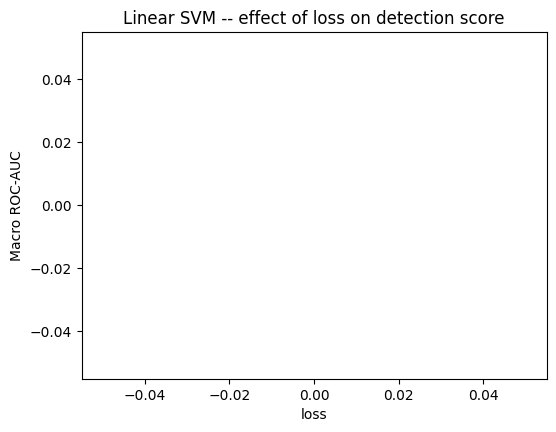

In [35]:
fig, ax = plt.subplots(figsize=(6, 4.5))

xs = [r["loss"] for r in svm_loss_results]
ys = [r["AUC"] for r in svm_loss_results]

bars = ax.bar(
    xs,
    ys,
    color=["#fdae6b", "#d62728"],
    alpha=0.85,
    edgecolor="grey",
    linewidth=0.5,
    width=0.5,
)

ax.set_xlabel("loss")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("Linear SVM -- effect of loss on detection score")
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.grid(alpha=0.3, axis="y")

for bar, y in zip(bars, ys):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


### Random Forest

Three sweeps spanning RF's three regularisation knobs:

- `n_estimators` (forest capacity -- more trees, lower variance)
- `max_depth` (per-tree depth, controls fit-to-noise)
- `min_samples_leaf` (minimum samples per leaf, controls fit to rare positives)

Each sweep holds the other two at the section-5 defaults. RF takes ~7 minutes per fit at our scale (100 trees, depth 15, 41k rows, 234 outputs); the three sweeps below take ~75 minutes combined. Re-running this section is the largest single time cost in the notebook.

No feature standardisation is needed -- trees split on raw thresholds.


#### `n_estimators` -- number of trees

More trees lowers prediction variance via averaging. Train time grows linearly. Most ensembles saturate well before the textbook recommendation of "hundreds"; the question is whether 100 is past or before our saturation point.


In [36]:
rf_n_results = []

for n in [50, 100]:
    t0 = time.time()
    clf = RandomForestClassifier(
        n_estimators=n,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED,
    )
    clf.fit(X_train, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_sc_val, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    rf_n_results.append({"n_estimators": n, "AUC": auc, "Train (s)": dt})
    print(f"  n_estimators = {n:<4}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(rf_n_results)


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

xs = [r["n_estimators"] for r in rf_n_results]
ys = [r["AUC"] for r in rf_n_results]

ax.plot(xs, ys, "o-", color="#2ca02c", linewidth=2, markersize=9)
ax.axhline(0.7564, ls="--", color="grey", alpha=0.6, label="default (n_estimators=100)")

ax.set_xlabel("n_estimators")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("Random Forest -- effect of n_estimators on detection score")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

for x, y in zip(xs, ys):
    ax.annotate(
        f"{y:.4f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


#### `max_depth` -- per-tree depth

Shallower trees are heavily regularised and prone to underfit; unlimited depth (`None`) fits each leaf to its training subset, which on a 0.4% positive rate can mean a single noisy clip dictates a leaf. The current value 15 sits in between.


In [ ]:
rf_d_results = []

for depth in [10, 15]:
    t0 = time.time()
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED,
    )
    clf.fit(X_train, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_sc_val, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    rf_d_results.append({"max_depth": str(depth), "AUC": auc, "Train (s)": dt})
    print(f"  max_depth = {depth:<5}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(rf_d_results)


  max_depth = 10     AUC = 0.7307   (307.7s)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

xs = [r["max_depth"] for r in rf_d_results]
ys = [r["AUC"] for r in rf_d_results]

bars = ax.bar(
    xs, ys, color="#2ca02c", alpha=0.85, edgecolor="grey", linewidth=0.5, width=0.55
)
ax.axhline(0.7564, ls="--", color="grey", alpha=0.6, label="default (max_depth=15)")

ax.set_xlabel("max_depth")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("Random Forest -- effect of max_depth on detection score")
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)

for bar, y in zip(bars, ys):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


#### `min_samples_leaf` -- minimum samples per leaf

At 0.4% positive rate per species, a leaf containing only 1 sample (sklearn default) can mean one noisy training clip dictates the prediction. Larger `min_samples_leaf` forces leaves to aggregate over more samples, which dampens fits to outliers but also smooths over genuine rare-species signal.


In [ ]:
rf_l_results = []

for m in [1, 5]:
    t0 = time.time()
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=m,
        n_jobs=-1,
        random_state=SEED,
    )
    clf.fit(X_train, Y_train[:, active_cols])
    auc = macro_auc(predict_probs(clf, X_sc_val, active_cols), Y_sc_val)
    dt = round(time.time() - t0, 1)

    rf_l_results.append({"min_samples_leaf": m, "AUC": auc, "Train (s)": dt})
    print(f"  min_samples_leaf = {m:<3}  AUC = {auc:.4f}   ({dt}s)")

pd.DataFrame(rf_l_results)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

xs = [str(r["min_samples_leaf"]) for r in rf_l_results]
ys = [r["AUC"] for r in rf_l_results]

bars = ax.bar(
    xs, ys, color="#2ca02c", alpha=0.85, edgecolor="grey", linewidth=0.5, width=0.55
)
ax.axhline(
    0.7564, ls="--", color="grey", alpha=0.6, label="default (min_samples_leaf=5)"
)

ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("Macro ROC-AUC")
ax.set_title("Random Forest -- effect of min_samples_leaf on detection score")
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)

for bar, y in zip(bars, ys):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.002,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


### Summary

Compares the AUC range each hyperparameter produced.


In [ ]:
sweeps_summary = []


def _add(name, rows, key):
    aucs = [r["AUC"] for r in rows]
    sweeps_summary.append(
        {
            "Sweep": name,
            "Min AUC": round(min(aucs), 4),
            "Max AUC": round(max(aucs), 4),
            "Sensitivity": round(max(aucs) - min(aucs), 4),
        }
    )


_add("Pipeline -- SC_REPEATS", sc_repeats_results, "SC_REPEATS")
_add("LR -- C", lr_c_results, "C")
_add("LR -- class_weight", lr_cw_results, "class_weight")
_add("LR -- penalty", lr_pen_results, "penalty / solver")
_add("RF -- n_estimators", rf_n_results, "n_estimators")
_add("RF -- max_depth", rf_d_results, "max_depth")
_add("RF -- min_samples_leaf", rf_l_results, "min_samples_leaf")
_add("SVM -- C", svm_c_results, "C")
_add("SVM -- loss", svm_loss_results, "loss")

summary_df = (
    pd.DataFrame(sweeps_summary)
    .sort_values("Sensitivity", ascending=False)
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
order = summary_df.iloc[::-1]
bars = ax.barh(
    order["Sweep"],
    order["Sensitivity"],
    color="#4a7db5",
    alpha=0.85,
    edgecolor="grey",
    linewidth=0.5,
)
ax.set_xlabel("Sensitivity (AUC range across sweep)")
ax.set_title("Hyperparameter sensitivity -- which knob moves the needle?")
ax.grid(alpha=0.3, axis="x")

for bar, val in zip(bars, order["Sensitivity"]):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(
    Path("figures") / "hyperparam_sensitivity.png", dpi=120, bbox_inches="tight"
)
plt.show()
